In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob


In [ ]:
# Define map direcotory path
file_path = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20'

# file_path = '/Users/evillz/Data/CTC44/CTC_chirp_yogesh/psnex_map___2025.03.21_19.44.03.14'
# file_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45'



# Find CSV files in the specified directory
csv_files = maps.find_csv_files(file_path)

# Get the first CSV file found (if any)
map_path_csv = csv_files[0]

# load Map parameters 
params = maps.get_map_parameters(file_path)

Found 1 CSV files:
  - CTC45_map1_PFQNM.csv
detected PS-NEX map folder


Analyzing map: /Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20/CTC45_map1_PFQNM.csv
y_sens_um: 3.96, x_sens_um: 5.685
# of files analyzed: 1024, closest shape: 32 x 32
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX map folder
detected PS-NEX 

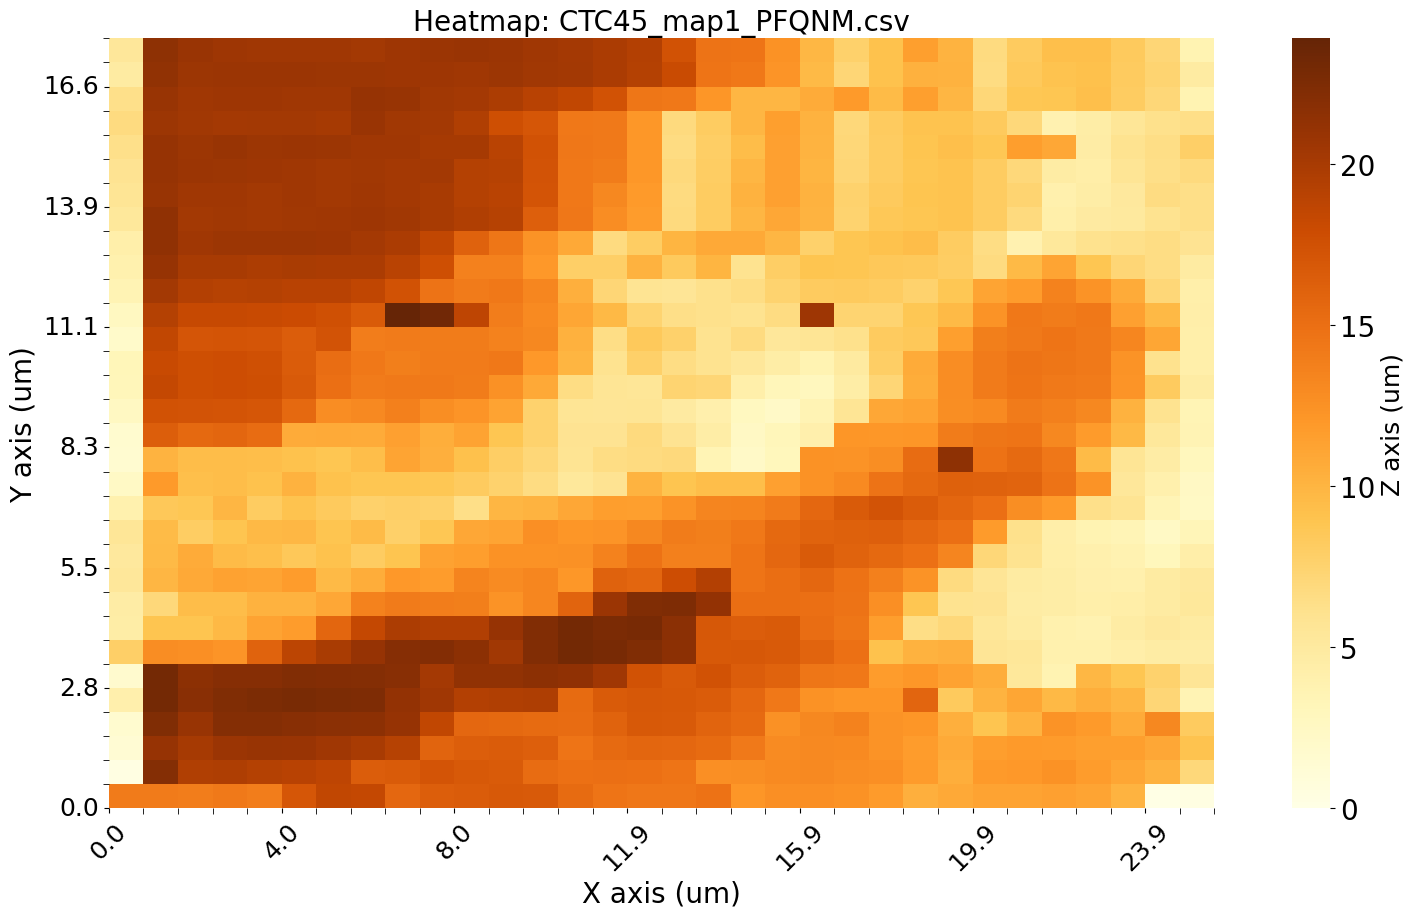

In [4]:
map_test_um_zeroed, x_axis, y_axis = maps.load_2d_map_file_csv (map_path_csv, params)
df_map, map_x_pix, map_y_pix , params = maps.load_map_file_square_tdms(file_path)

# # need

bool_error, mismatch_indices = maps.check_map_indice_integrity(df_map, map_x_pix, map_y_pix)
if bool_error:
    x_pos_1d, y_pos_1d, curve_index = maps.generate_xy_map_positions(map_x_pix=map_x_pix, map_y_pix=map_y_pix)
    x_indices = x_pos_1d
    y_indices = y_pos_1d
    print ('Map indices were regenerated due to integrity error')   

    # sort mismatch indices based on time from file ID
    df_time = maps.compute_time_difference(file_path)

    # Remove duplicates from df_time based on filepath (keep first occurrence)
    df_time = df_time.drop_duplicates(subset='filepath', keep='first')

    # Merge based on filepath - this should now be 1:1
    df_merged_tdms = pd.merge(df_map, df_time, on='filepath', how='left')

    # Check if we have the expected number of rows
    print(f"df_map rows: {len(df_map)}")
    print(f"df_time rows: {len(df_time)}")
    print(f"df_merged_tdms rows: {len(df_merged_tdms)}")




    # replace curve_index in df_map
    # df_merged_tdms['curve_index'] = curve_index
    # df_merged_tdms['x_index'] = x_indices
    # df_merged_tdms['y_index'] = y_indices  



# # bool_error, mismatch_indices = maps.check_map_indice_integrity(df_merged_tdms, map_x_pix, map_y_pix)


# # # replace nan with 0 for all columns
# df_merged_tdms = df_merged_tdms.fillna(0)
